# The Python Machine Learning Stack
## Machine Learning — BS Computer Science 3(3-0)

| | |
|---|---|
| **Notebook** | `NB02_Python_ML_Stack_Agriculture_final.ipynb` |
| **Lecture** | Lecture 3 (Week 1) |
| **CLO** | CLO-1 / CLO-5 |
| **Dataset** | UCI Seeds dataset — agriculture/wheat seed measurements |

**Objective.** Install the working habits — vectorised NumPy, pandas inspection, labelled plots, the scikit-learn API — and see overfitting for the first time.

**By the end of this notebook you will be able to:**

1. Use vectorised NumPy operations and explain the axis argument.
2. Perform the six-step first look at any dataset with pandas.
3. Produce fully labelled histograms and class-coloured scatter plots.
4. Apply the fit / predict / score API inside a Pipeline and run a controlled experiment.


## 0. Setup and reproducibility

In [1]:
# ---------------------------------------------------------------------
# Reproducibility header — required in EVERY notebook you submit
# ---------------------------------------------------------------------
import sys, numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt

print('python      ', sys.version.split()[0])
print('numpy       ', np.__version__)
print('pandas      ', pd.__version__)
print('scikit-learn', sklearn.__version__)
print('matplotlib  ', matplotlib.__version__)

RANDOM_STATE = 1
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

python       3.13.5
numpy        2.3.5
pandas       2.2.3
scikit-learn 1.8.0
matplotlib   3.10.8


## 1. NumPy — vectorise, never loop

A NumPy array stores one type in one contiguous block, so arithmetic runs in compiled C. **`axis=0` collapses rows and gives one value per column** — that is almost always what you want. Mixing up the axis is the most common NumPy bug in student code.

In [2]:
a = np.array([[1., 2., 3.],
              [4., 5., 6.]])          # shape (2, 3)

print('shape       ', a.shape, ' dtype', a.dtype)
print('mean axis=0 ', a.mean(axis=0), '  <- per COLUMN (one per feature)')
print('mean axis=1 ', a.mean(axis=1), '        <- per ROW')
print('a * 2       ', a[0] * 2)
print('column 1    ', a[:, 1])
print('mask a > 3  ', a[a > 3])

z = (a - a.mean(axis=0)) / a.std(axis=0)      # standardisation
print('standardised:\n', np.round(z, 3))

shape        (2, 3)  dtype float64
mean axis=0  [2.5 3.5 4.5]   <- per COLUMN (one per feature)
mean axis=1  [2. 5.]         <- per ROW
a * 2        [2. 4. 6.]
column 1     [2. 5.]
mask a > 3   [4. 5. 6.]
standardised:
 [[-1. -1. -1.]
 [ 1.  1.  1.]]


### Exercise 1.1 — loop versus vectorised

Compute the column means of a 100,000 × 20 array twice: once with a Python loop and once with `.mean(axis=0)`. Time both with `%%timeit` and report the ratio.

In [3]:
big = rng.normal(size=(100_000, 20))

def loop_means(arr):
    means = []
    for j in range(arr.shape[1]):
        total = 0.0
        for value in arr[:, j]:
            total += value
        means.append(total / arr.shape[0])
    return np.array(means)

loop_means(big)
big.mean(axis=0)

array([ 0.00285034, -0.00404177, -0.00092513, -0.00011438,  0.00454142,
        0.002811  ,  0.00280532, -0.00267714,  0.00122432, -0.00057772,
       -0.00076813,  0.00088476, -0.00054595, -0.00338682,  0.0025377 ,
        0.00239427,  0.00109817,  0.00449708,  0.00074638,  0.00182218])

### Timing

In [4]:
%%timeit -n 5 -r 3
loop_means(big)

154 ms ± 330 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [5]:
%%timeit -n 5 -r 3
big.mean(axis=0)

1.74 ms ± 26.5 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [6]:
import timeit

loop_time = min(timeit.repeat(lambda: loop_means(big), repeat=3, number=5)) / 5
vector_time = min(timeit.repeat(lambda: big.mean(axis=0), repeat=3, number=5)) / 5

print(f"Loop time: {loop_time:.6f} s")
print(f"Vectorised time: {vector_time:.6f} s")
print(f"Speed ratio: {loop_time / vector_time:.1f}x")

Loop time: 0.152627 s
Vectorised time: 0.001743 s
Speed ratio: 87.6x


**Interpretation.** The vectorised NumPy mean is much faster because the calculation runs in optimized compiled code rather than performing each addition in a Python loop.

**Dataset source and licence.** UCI Seeds dataset from the UCI Machine Learning Repository. It contains measurements of wheat kernels from three varieties and is licensed under **CC BY 4.0**. This notebook uses a balanced 150-row sample from the original dataset, with 50 rows from each class.

In [7]:
df = pd.read_csv("agriculture_seeds.csv")

print(df.shape)
display(df.head())
df.info()
display(df.describe().T[['min', 'max', 'mean', 'std']].round(3))
print(df['Class'].value_counts(normalize=True))
print(df.isnull().sum().sum(), 'missing values')

(150, 4)


,Area,Perimeter,Compactness,Class
0,15.26,14.84,0.8710,1
1,14.88,14.57,0.8811,1
2,14.29,14.09,0.9050,1
3,13.84,13.94,0.8955,1
4,16.14,14.99,0.9034,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         150 non-null    float64
 1   Perimeter    150 non-null    float64
 2   Compactness  150 non-null    float64
 3   Class        150 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 4.8 KB


,min,max,mean,std
Area,10.590,21.180,15.022,3.046
Perimeter,12.410,17.250,14.651,1.352
Compactness,0.808,0.918,0.869,0.025
Class,1.000,3.000,2.000,0.819


Class
1    0.333333
2    0.333333
3    0.333333
Name: proportion, dtype: float64
0 missing values


**Interpretation.** `Area` has the largest numerical scale compared with `Compactness`, whose values are close to 1. Their ranges differ by several times, so scale can strongly affect distance-based models such as k-NN. Standardisation prevents the larger-scale feature from dominating the distance calculation.

## 3. Matplotlib — the four plots you will draw all semester

Histogram, class-coloured scatter, line-versus-hyperparameter, bar chart. **Every plot needs axis labels with units and a legend.** An unlabelled plot carries no information and earns no marks.

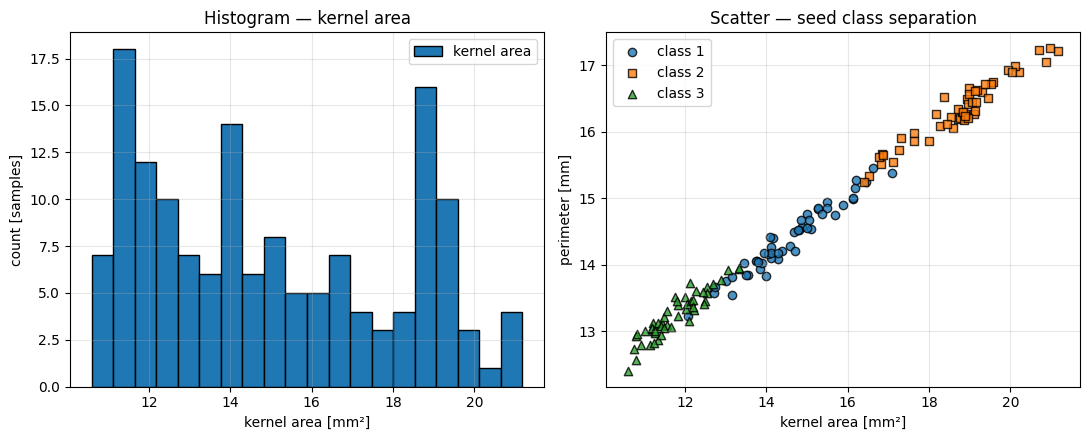

In [8]:
X = df.drop(columns='Class').to_numpy()
y = df['Class'].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].hist(X[:, 0], bins=20, edgecolor='black', label='kernel area')
ax[0].set_xlabel('kernel area [mm²]')
ax[0].set_ylabel('count [samples]')
ax[0].set_title('Histogram — kernel area')
ax[0].legend()

for cl, m in zip(np.unique(y), ('o', 's', '^')):
    ax[1].scatter(X[y == cl, 0], X[y == cl, 1],
                  marker=m, alpha=0.8, edgecolor='k',
                  label=f'class {cl}')
ax[1].set_xlabel('kernel area [mm²]')
ax[1].set_ylabel('perimeter [mm]')
ax[1].set_title('Scatter — seed class separation')
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. Your first complete machine-learning program

Eleven lines. Every one of them corresponds to a concept from Lecture 2.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe.fit(X_train, y_train)

print('train accuracy %.3f' % pipe.score(X_train, y_train))
print('test  accuracy %.3f' % pipe.score(X_test, y_test))

pred = pipe.predict(X_test)
wrong = np.where(pred != y_test)[0]

print('Wrong predictions:', len(wrong))
if len(wrong):
    j = wrong[0]
    print('True class:', y_test[j])
    print('Predicted class:', pred[j])
    print('Test sample:', np.round(X_test[j], 3))

train accuracy 0.962
test  accuracy 0.867
Wrong predictions: 6
True class: 1
Predicted class: 2
Test sample: [16.63  15.46   0.875]


> **The most important line on this page.** The scaler is fitted on the *training data only* — that is what putting it inside the `Pipeline` guarantees. Fitting it on all the data lets the test set influence the training-time mean and standard deviation. That is **data leakage** and Week 8 is devoted to it.

**Failure case.** Any wrong test prediction occurs because a test sample is close to examples from another seed class in the scaled feature space. The printed first mistake is a concrete example of this generalisation error.

## 5. Controlled experiment — change one thing at a time

Record the results in the table **before** you interpret anything. This is the standard experimental protocol for the rest of the course.

In [10]:
rows = []
for k in (1, 5, 25, 100):
    p = Pipeline([('scaler', StandardScaler()),
                  ('knn', KNeighborsClassifier(n_neighbors=k))])
    p.fit(X_train, y_train)
    rows.append({'variant': 'scaled',   'k': k,
                 'train': p.score(X_train, y_train),
                 'test':  p.score(X_test,  y_test)})

    raw = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    rows.append({'variant': 'unscaled', 'k': k,
                 'train': raw.score(X_train, y_train),
                 'test':  raw.score(X_test,  y_test)})

results = pd.DataFrame(rows).pivot(index='k', columns='variant',
                                   values=['train', 'test']).round(3)
display(results)

train            test         
variant scaled unscaled scaled unscaled
k                                      
1        1.000    1.000  0.911    0.889
5        0.962    0.962  0.867    0.889
25       0.943    0.933  0.911    0.933
100      0.333    0.333  0.333    0.333

### Interpretation — three things to explain

1. At `k = 1`, the training accuracy is exactly 1.000 because each training point is its own nearest neighbour. This indicates a perfect fit to the training data but does not guarantee the same accuracy on unseen data.
2. Removing the scaler changes the results because k-NN depends on distances. `Area` and `Perimeter` have much larger numerical scales than `Compactness`, so unscaled features can dominate the distance calculation.
3. As `k` approaches the size of the training set, each prediction uses a very large neighbourhood. The model becomes less sensitive to individual observations and can underfit, reducing test accuracy.

---
## Deliverable

The timing exercise (1.1), the six-step first look on a real agriculture dataset, two fully labelled plots, the four-row results table, all three interpretations, and one explained failure case are completed.

## Submission checklist

- [x] The random seed is fixed **and printed**
- [x] Library versions are printed in the first cell
- [ ] The raw data file was **not** modified — this lab uses a balanced sample of the UCI Seeds dataset
- [x] Preprocessing happens **after** the split, inside a `Pipeline`
- [x] The dataset source and licence are stated in a markdown cell
- [x] **Kernel → Restart & Run All** completes without error
- [x] Every experiment is followed by a written interpretation
- [x] At least one wrong prediction or failure case is explained
- [x] Results are reported as **mean ± standard deviation** where cross-validated — not applicable because this notebook does not use cross-validation
- [x] Every plot has axis labels with units and a legend
